<a href="https://colab.research.google.com/github/uniitee/Celebal_Excellence_Intern_2026/blob/main/Week2_UmaGhildiyal_TeslaEADeliveriesAndProduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!pip install opendatasets

In [33]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025")

Skipping, found downloaded files in "./tesla-ea-deliveries-and-production-data20152025" (use force=True to force download)


# Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading The DataSet

In [35]:
df = pd.read_csv("/content/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [36]:
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [37]:
df.shape

(2640, 12)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [39]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [40]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### 1. Overall Observations::
- The dataset has 0 missing values across all 12 columns.

### 2.  Temporal Data Distribution
- Year : 2015 to 2025 -> 11yrs data
- Months : 1 to 12 -> complete monthly

### 3. Production & Deliveries
- ED avg : 9,922 units
- ED range : 48 - 25,704 -> (large variability)
- PU avg : 10,655 units
- PU range : 50 - 28939 -> (high variability)
- On avegrage : production slightly > deliveries

### 4. Price & EV Specifications
- Price range avg : 50,003 - 119,965
- A wide range of pricing based on region or model.
- Battery Capacity Mean : 87 kWh
- Battery Capacity Range = 60–120 kWh
- Range Mean = 500 km

### 5. CO2 saved (tons)
- mean: 744
- range : 3 - 2548 -> (high variability)

### 6. Categorical Values
- Region
- Model
- Source Type

# Exploratory Data Analysis

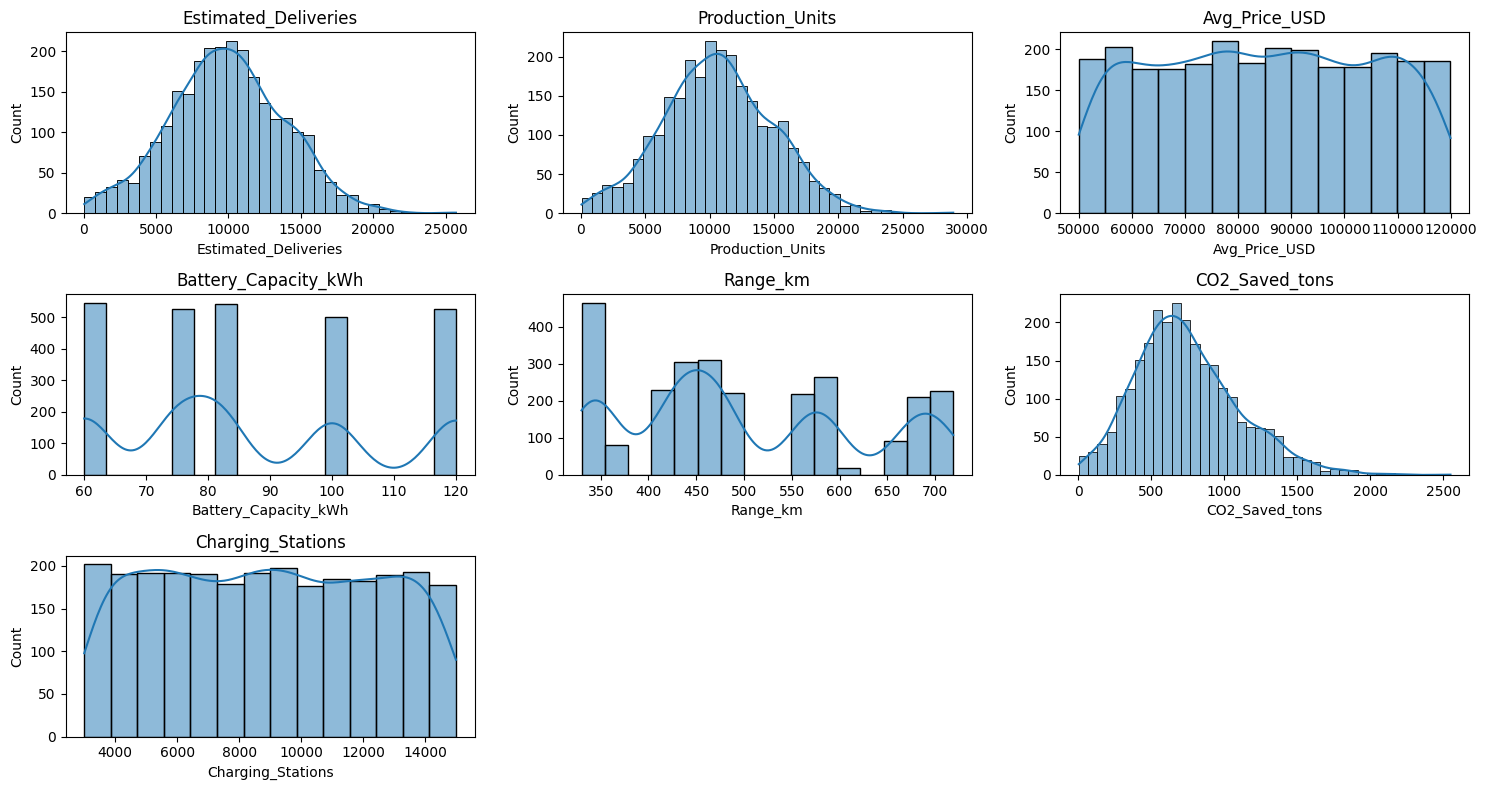

In [41]:
# Histogram plot for Analysing Numeric Features Distribution
num_cols_hist = ['Estimated_Deliveries','Production_Units', 'Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(15,8))

for col in num_cols_hist:
    plt.subplot(3,3,num_cols_hist.index(col)+1)
    sns.histplot(df[col],kde=True,)
    plt.title(col)

plt.tight_layout()
plt.show()

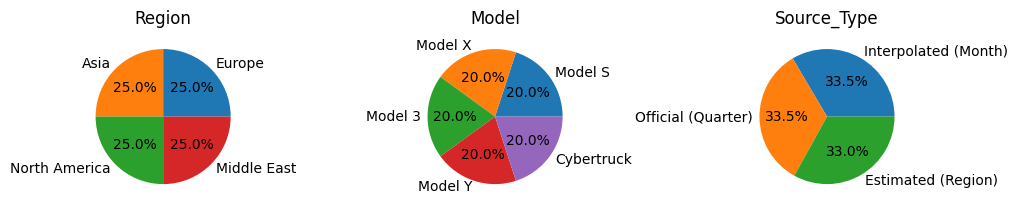

In [42]:
# Pie Chart for Understanding Categorical Feature's Distribution
cat_cols_pie = ['Region','Model','Source_Type']
plt.figure(figsize=(10,5))

for col in cat_cols_pie:
    plt.subplot(1,3,cat_cols_pie.index(col)+1)
    plt.pie(df[col].value_counts(), labels=df[col].value_counts().index,autopct='%1.1f%%')
    plt.title(col)

plt.tight_layout()
plt.show()

### Categorical Data
- equal distribution for each category in eacg categorical feature

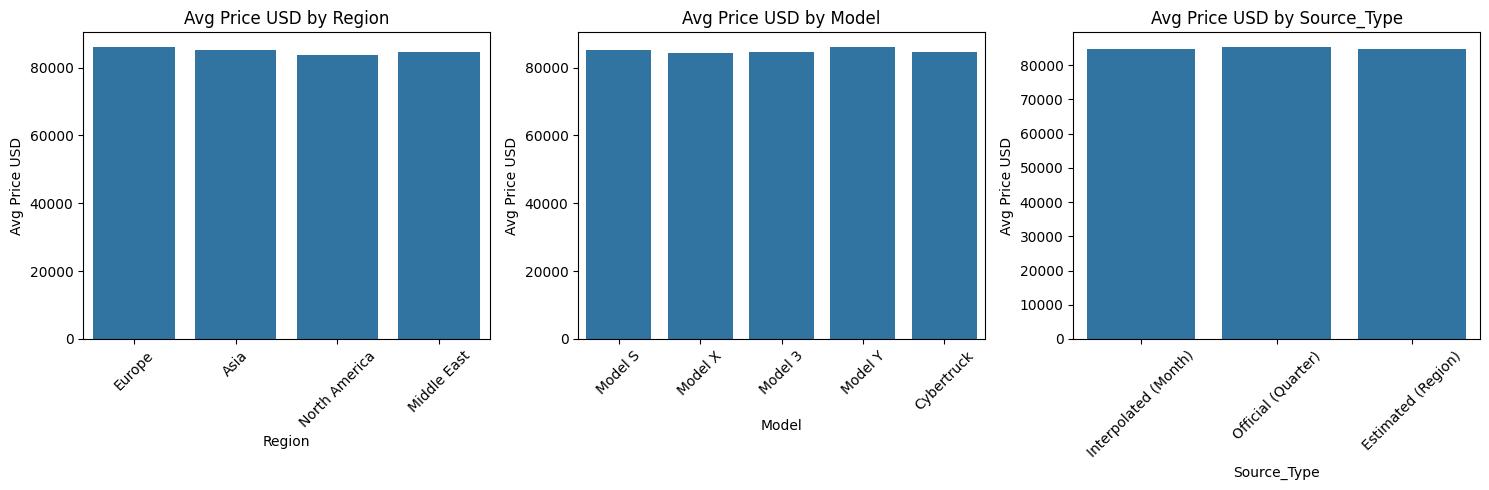

In [43]:
# Avg_Price_USD by Region, Model, Source_Type

plt.figure(figsize=(15,5))

for i, col in enumerate(cat_cols_pie):
    plt.subplot(1, 3, i+1)
    sns.barplot(
        x=col,
        y='Avg_Price_USD',
        data=df,
        errorbar=None
    )
    plt.xlabel(col)
    plt.ylabel('Avg Price USD')
    plt.title(f'Avg Price USD by {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

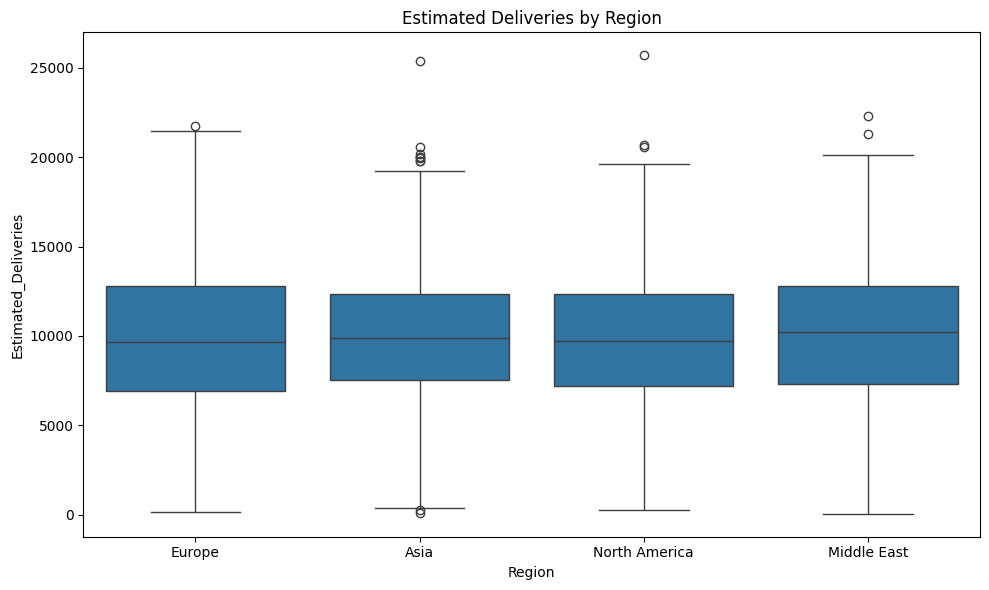

In [44]:
# Box Plot for Estimated_Deliveries by Region
if 'Region' in df.columns and 'Estimated_Deliveries' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Region', y='Estimated_Deliveries', data=df)
    plt.title('Estimated Deliveries by Region')
    plt.tight_layout()
    plt.savefig('estimated_deliveries_boxplot.png')
    plt.show()

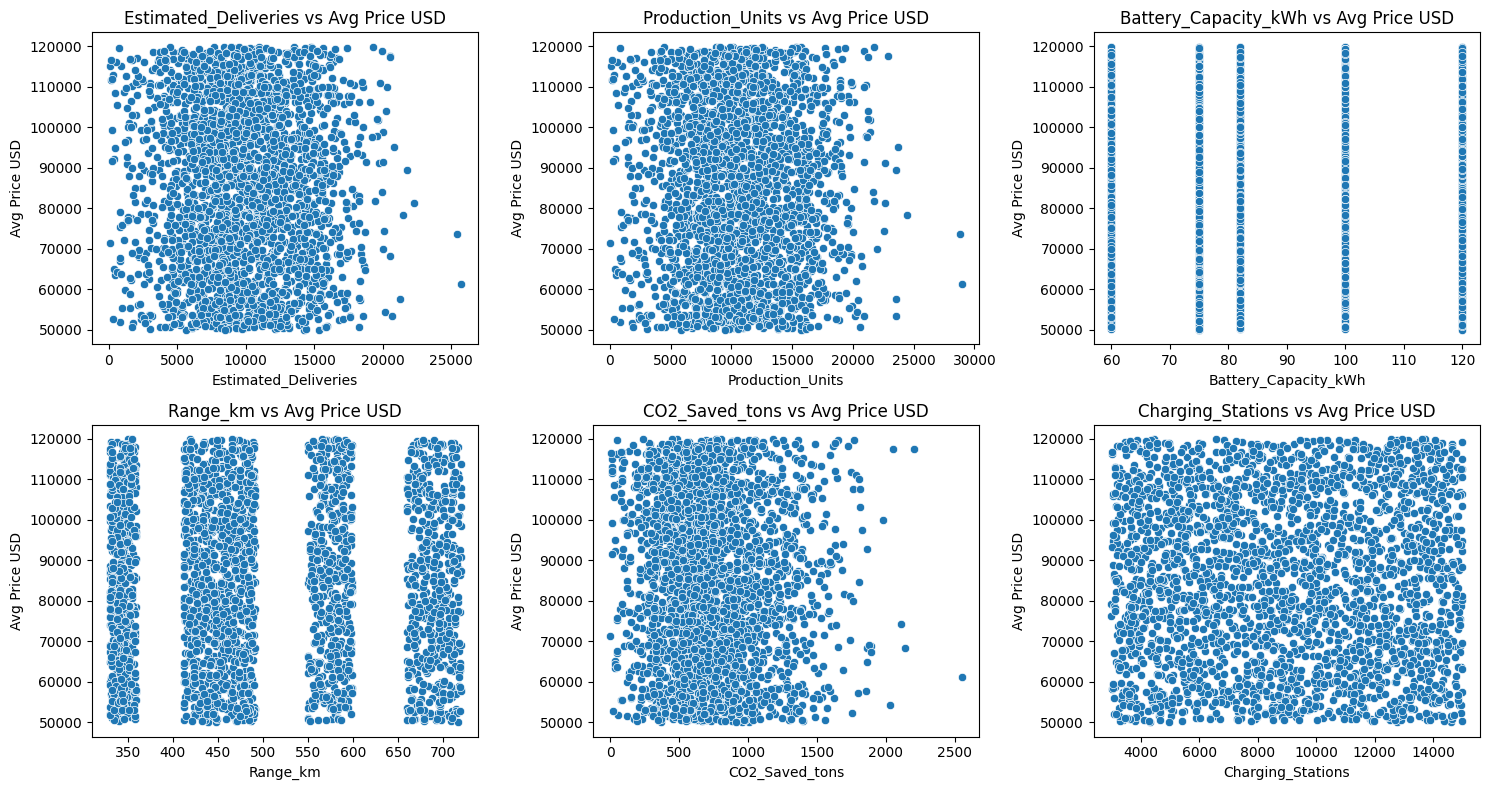

In [45]:
# Numerical Columns with Avg_Price_Usd
cols_scatter = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(15,8))

for col in cols_scatter:
    plt.subplot(2,3,cols_scatter.index(col)+1)
    sns.scatterplot(
        x=df[col],
        y=df['Avg_Price_USD']
    )
    plt.xlabel(col)
    plt.ylabel('Avg Price USD')
    plt.title(f'{col} vs Avg Price USD')

plt.tight_layout()
plt.show()

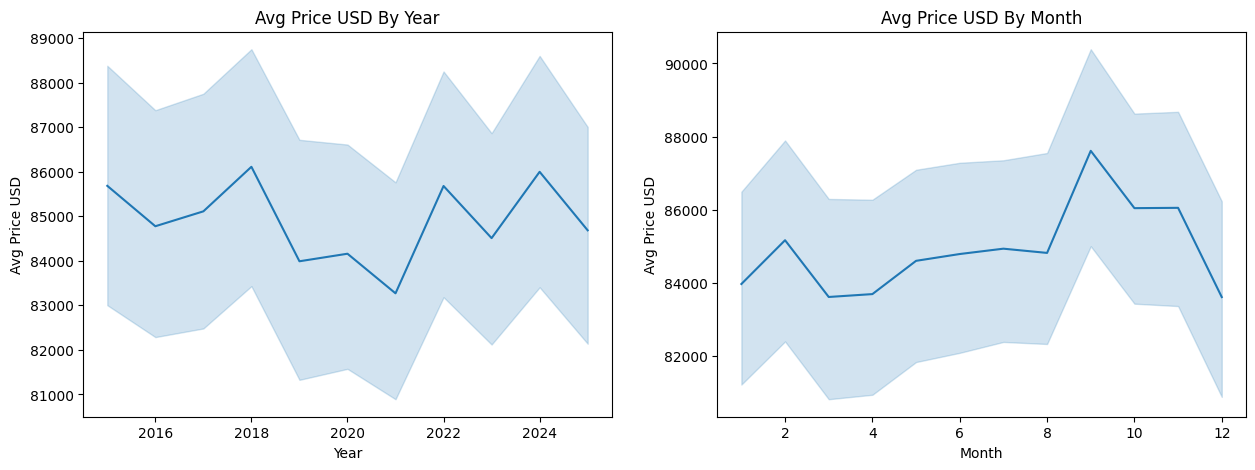

In [46]:
temporal_cols = ['Year','Month']
plt.figure(figsize=(15,5))

for col in ['Year','Month']:
    plt.subplot(1,2, temporal_cols.index(col)+1)
    sns.lineplot(
        x=df[col],
        y='Avg_Price_USD',
        data=df
    )
    plt.xlabel(col)
    plt.ylabel('Avg Price USD')
    plt.title(f'Avg Price USD By {col}')

plt.show()

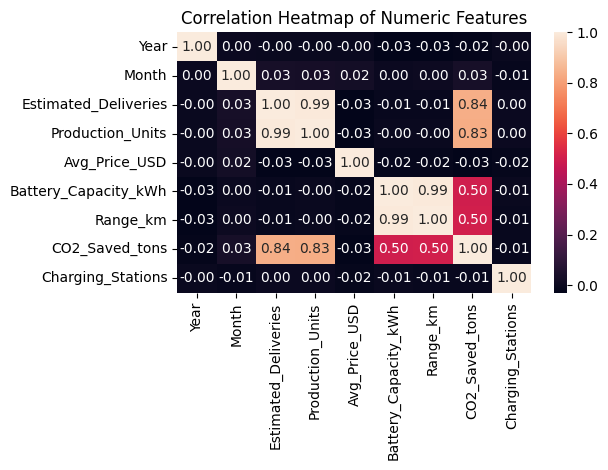

In [47]:
# correlation analysis for numeric features
numeric_df = df.select_dtypes(include=[np.number])

# Check number of numeric columns; perform correlation heatmap if there are four or more
if numeric_df.shape[1] >= 4:
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient numeric columns for a correlation heatmap.')

- Higher cars produced -> Higher cars delivered
> strongest predictive features.
- Bigger battery -> larger driving range
- More EV deliveries -> more CO2 saved
> (CO2 saved only be known after deliveries happen, thus removing CO2_Saved_tons from training)
- Avg Price : weakly correlated with most variables.



# Feature Engineering

In [48]:
df1 = df.copy()

In [49]:
df1['Date'] = pd.to_datetime(df1[['Year', 'Month']].assign(DAY=1))
df1['Price_per_km'] = df1['Avg_Price_USD'] / df1['Range_km']

In [50]:
df1 = df1.sort_values('Date')

In [51]:
df1['Year'] = df1['Date'].dt.year
df1['Quarter'] = df1['Date'].dt.quarter

df1['Month_sin'] = np.sin(
    2*np.pi*df1['Month']/12
)

df1['Month_cos'] = np.cos(
    2*np.pi*df1['Month']/12
)

In [52]:
# dropping CO2 Saved, Year and Month
df1.drop('CO2_Saved_tons', axis=1, inplace=True)
df1.drop('Year', axis=1, inplace=True)
df1.drop('Month', axis=1, inplace=True)

In [53]:
df1.head()

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,Source_Type,Charging_Stations,Date,Price_per_km,Quarter,Month_sin,Month_cos
872,Asia,Model Y,12446,13885,55183.13,60,340,Official (Quarter),4390,2015-01-01,162.303324,1,0.5,0.866025
2354,Middle East,Model 3,11446,12752,89289.40,100,588,Estimated (Region),8925,2015-01-01,151.852721,1,0.5,0.866025
2312,Middle East,Cybertruck,8803,9344,102888.58,60,336,Interpolated (Month),3923,2015-01-01,306.216012,1,0.5,0.866025
2293,North America,Cybertruck,6367,6802,104962.32,82,459,Estimated (Region),9170,2015-01-01,228.676078,1,0.5,0.866025
2215,Asia,Model 3,8795,9165,87988.73,82,456,Official (Quarter),12626,2015-01-01,192.957741,1,0.5,0.866025


# TimeSeries Split and Train Test Split

In [54]:
# Train Test Split w/o using random split for time series data
train_size = int(0.8 * len(df1))
train_data = df1.iloc[:train_size]
test_data = df1.iloc[train_size:]

In [55]:
train_data.shape, test_data.shape

((2112, 14), (528, 14))

In [56]:
# Feature Selection
X_train = train_data.drop(['Estimated_Deliveries', 'Date'], axis=1)
y_train = train_data['Estimated_Deliveries']

X_test = test_data.drop(['Estimated_Deliveries', 'Date'], axis=1)
y_test = test_data['Estimated_Deliveries']

# Model Pipelines



In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score

In [58]:
#column transformers
cat_cols = ['Region','Model','Source_Type']
num_cols = [
    col for col in X_train.columns
    if col not in cat_cols
]
# convering num_cols and cat cols into index position
num_cols = [X_train.columns.get_loc(col) for col in num_cols]
cat_cols = [X_train.columns.get_loc(col) for col in cat_cols]

# Transformer, trf1 for OHE
trf1 = ColumnTransformer([
    ('onehot', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)
], remainder='passthrough')

# Transformer, trf2 for scaling the data
trf2 = ColumnTransformer([
    ('scaler', StandardScaler(), num_cols)
])


In [59]:
# Creating Pieline
pipe = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('model', LinearRegression())
])

In [60]:
print(type(X_train))
print(X_train.head())

<class 'pandas.core.frame.DataFrame'>
             Region       Model  Production_Units  Avg_Price_USD  \
872            Asia     Model Y             13885       55183.13   
2354    Middle East     Model 3             12752       89289.40   
2312    Middle East  Cybertruck              9344      102888.58   
2293  North America  Cybertruck              6802      104962.32   
2215           Asia     Model 3              9165       87988.73   

      Battery_Capacity_kWh  Range_km           Source_Type  Charging_Stations  \
872                     60       340    Official (Quarter)               4390   
2354                   100       588    Estimated (Region)               8925   
2312                    60       336  Interpolated (Month)               3923   
2293                    82       459    Estimated (Region)               9170   
2215                    82       456    Official (Quarter)              12626   

      Price_per_km  Quarter  Month_sin  Month_cos  
872     162.30

In [61]:
pipe.fit(
    X_train,
    y_train
)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [0, 1, 6])])),
                ('trf2',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  [2, 3, 4, 5, 7, 8, 9, 10,
                                                   11])])),
                ('model', LinearRegression())])

In [62]:
# Evaluation
y_pred = pipe.predict(X_test)

print("R2: ", r2_score(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))

R2:  0.9863368307564921
MAE:  352.38510668510713
MSE:  181659.1195187067


# Hyperparameter tuning

In [69]:
from sklearn.linear_model import Ridge

pipe = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'model__alpha': 0.01}


In [70]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test,y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

R2: 0.9863368592012121
MAE: 352.38552347995727
RMSE: 426.2144311622849
